# INTRODUCTION
This notebook will be used to centered and crop the images (painting and celeb) in 256*256 images.

# Libraries

# DECTION VISAGE, CROP 

In [1]:
import cv2, numpy as np
from PIL import Image
import face_recognition as fr

def align_and_square_crop(pil_img, margin=1.6):
    """Aligne sur les yeux et crop carré autour du visage.
    margin: taille du carré en multiples de la distance entre les yeux (1.6~1.8 = portrait serré)."""
    img = np.array(pil_img.convert("RGB"))
    locs = fr.face_locations(img, model="hog")  # rapide; "cnn" si GPU
    if not locs:
        return None  # on gèrera un fallback plus bas
    # landmarks (yeux)
    marks = fr.face_landmarks(img, locs)[0]
    left_eye  = np.mean(marks["left_eye"], axis=0)
    right_eye = np.mean(marks["right_eye"], axis=0)

    # angle pour aligner les yeux
    dy, dx = right_eye[1]-left_eye[1], right_eye[0]-left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D(tuple(left_eye), angle, 1.0)
    rot = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    # nouvelles coords des yeux après rotation
    ones = np.array([[left_eye[0], left_eye[1], 1],[right_eye[0], right_eye[1], 1]]).T
    new = (M @ ones).T
    le, re = new[0], new[1]
    eye_dist = np.linalg.norm(le - re)

    # centre entre les yeux; carré basé sur margin*eye_dist
    cx, cy = ((le+re)/2).astype(int)
    half = int(margin*eye_dist/2)
    x1, y1 = max(0, cx-half), max(0, cy-half)
    x2, y2 = min(w, cx+half), min(h, cy+half)
    crop = rot[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    # rendre parfaitement carré par padding si besoin
    ch, cw = crop.shape[:2]
    s = max(ch, cw)
    canvas = np.zeros((s, s, 3), dtype=np.uint8)
    yoff = (s-ch)//2; xoff = (s-cw)//2
    canvas[yoff:yoff+ch, xoff:xoff+cw] = crop
    return Image.fromarray(canvas)


# FALL BACK S'IL N'Y A PAS DE VISAGE DETECTE (TROP ARTISTIQUE)

In [2]:
def safe_center_square(pil_img):
    w, h = pil_img.size
    s = min(w, h)
    left = (w - s)//2
    top  = (h - s)//2
    return pil_img.crop((left, top, left+s, top+s))


# Retirer les cadres/bords (fréquents en peintures)

In [3]:
def trim_border(pil_img, thresh=12):
    img = pil_img.convert("RGB")
    npi = np.asarray(img)
    # bordures: faible gradient → on cherche bande quasi uniforme
    gray = cv2.cvtColor(npi, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 40, 120)
    # somme d'edges par rangée/colonne
    top = np.argmax(np.cumsum(edges.any(1)) > 0)
    bottom = len(edges)-1 - np.argmax(np.cumsum(edges[::-1].any(1)) > 0)
    left = np.argmax(np.cumsum(edges.any(0)) > 0)
    right = edges.shape[1]-1 - np.argmax(np.cumsum(edges[:, ::-1].any(0)) > 0)

    # garde une marge si la détection est trop agressive
    top    = max(0, top - thresh)
    left   = max(0, left - thresh)
    bottom = min(edges.shape[0]-1, bottom + thresh)
    right  = min(edges.shape[1]-1, right + thresh)

    if right-left < 50 or bottom-top < 50:
        return pil_img  # éviter crop extrême
    return img.crop((left, top, right, bottom))


# Redimensionner + normaliser (256×256, [-1,1] pour CycleGAN)

In [4]:
import torchvision.transforms as T

to_256 = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(256)
])

def preprocess_painting(pil_img):
    img = trim_border(pil_img)
    aligned = align_and_square_crop(img)
    sq = aligned if aligned is not None else safe_center_square(img)
    return to_256(sq)


# Dédupliquer (facultatif mais utile)

In [5]:
from imagehash import phash
from collections import defaultdict

def dedupe_paths(paths, max_dist=4):
    seen = []
    keep, drop = [], []
    for p in paths:
        try:
            h = phash(Image.open(p).convert("RGB"))
        except:
            drop.append(p); continue
        matched = False
        for (hh, ref) in seen:
            if h - hh <= max_dist:
                drop.append(p); matched=True; break
        if not matched:
            seen.append((h, p)); keep.append(p)
    return keep, drop


# Boucle de traitement (portraits peints → 256×256 cohérents)

In [6]:
import os
from tqdm import tqdm

SRC = "../../data/raw/paint_portrait"     # tes 3500 peintures
DST = "../../data/processed/paint_portrait"         # sortie prête pour CycleGAN (domaine B)
os.makedirs(DST, exist_ok=True)

files = [os.path.join(SRC, f) for f in os.listdir(SRC) if f.lower().endswith((".jpg",".jpeg",".png",".webp"))]

# (optionnel) déduplication
# files, dropped = dedupe_paths(files)

for src in tqdm(files):
    try:
        img = Image.open(src).convert("RGB")
        out = preprocess_painting(img)
        out.save(os.path.join(DST, os.path.basename(src).rsplit(".",1)[0] + ".jpg"), quality=92)
    except Exception as e:
        print("skip:", src, e)


 52%|█████▏    | 1869/3592 [02:43<02:31, 11.41it/s]


KeyboardInterrupt: 

In [7]:
import os, sys, math, numpy as np
from PIL import Image, ImageOps
from tqdm import tqdm
import face_recognition as fr

SRC = "../../data/raw/paint_portrait"     # tes 3500 peintures
DST = "../../data/processed/paint_portrait"     # sortie (tête+épaules, 256x256)
os.makedirs(DST, exist_ok=True)

In [8]:
def crop_head_shoulders(pil_img, scale=2.8, out=256, model="hog"):
    """
    1) détecte le visage le plus grand
    2) agrandit la bbox par 'scale' pour inclure front + épaules
    3) découpe au carré, puis redimensionne en out x out (LANCZOS)
    Fallback : center-crop carré si aucun visage détecté.
    """
    img = np.array(pil_img.convert("RGB"))
    # Détection des visages
    boxes = fr.face_locations(img, model=model)  # "hog" (CPU) | "cnn" (GPU, + lent mais + robuste)
    if not boxes:
        # Fallback: center-crop carré assez large (90% du côté court), puis resize
        w, h = pil_img.size
        s = int(min(w, h) * 0.90)
        left, top = (w - s)//2, (h - s)//2
        crop = pil_img.crop((left, top, left+s, top+s))
        return ImageOps.fit(crop, (out, out), method=Image.Resampling.LANCZOS, centering=(0.5, 0.5))

    # On garde le visage le plus grand (utile si plusieurs personnes)
    top, right, bottom, left = sorted(
        boxes, key=lambda b: (b[2]-b[0]) * (b[1]-b[3]), reverse=True
    )[0]

    # Centre et taille de la bbox visage
    cx, cy = (left + right) // 2, (top + bottom) // 2
    face_w, face_h = (right - left), (bottom - top)

    # Côté du carré = max(face_w, face_h) * scale  (2.6–3.2 conseillé)
    side = int(max(face_w, face_h) * float(scale))
    if side <= 0:
        side = max(pil_img.size)  # garde sécurité

    # Coordonnées du carré (centré sur le visage)
    x1, y1 = cx - side // 2, cy - side // 2
    x2, y2 = x1 + side, y1 + side

    # Clamp dans l'image
    W, H = pil_img.size
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)

    # Si la zone est minuscule (tableaux en pied, visage très petit) → fallback plus large
    if (x2 - x1) < 64 or (y2 - y1) < 64:
        s = int(min(W, H) * 0.90)
        left, top = (W - s)//2, (H - s)//2
        crop = pil_img.crop((left, top, left+s, top+s))
    else:
        crop = pil_img.crop((x1, y1, x2, y2))

    # Resize carré propre en out x out
    return ImageOps.fit(crop, (out, out), method=Image.Resampling.LANCZOS, centering=(0.5, 0.5))


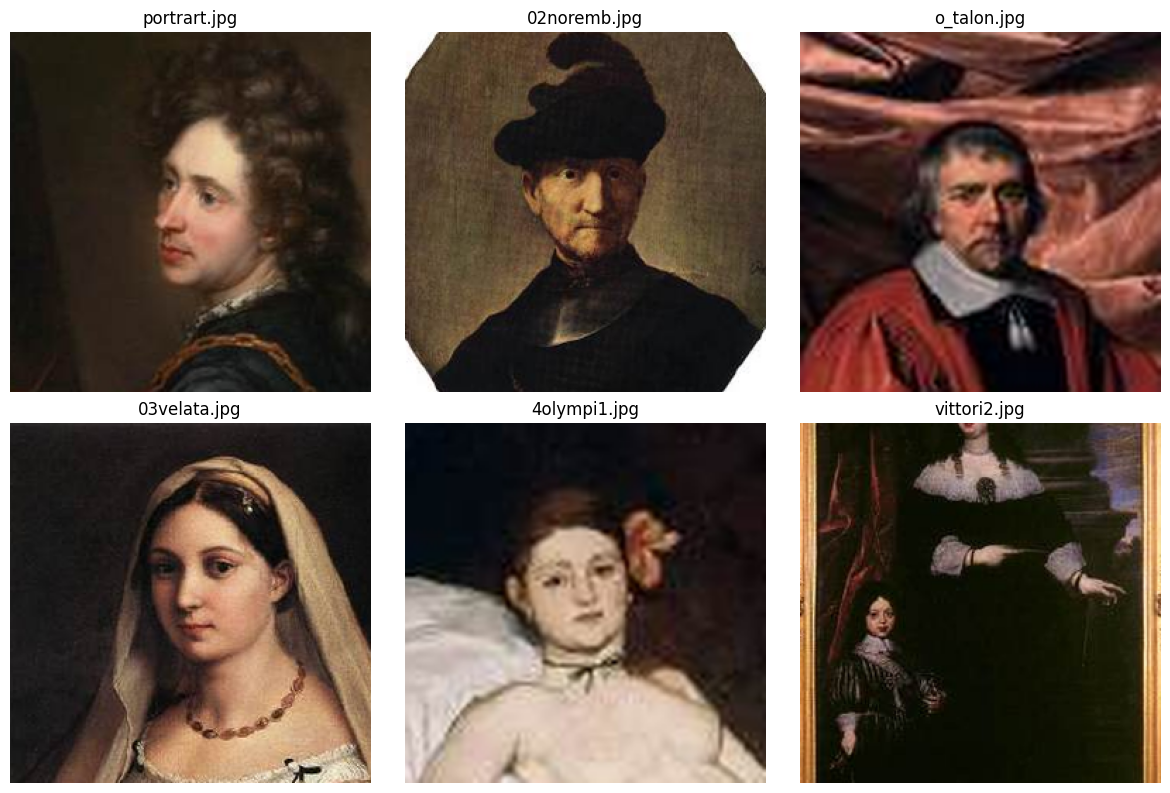

In [10]:
import random
import matplotlib.pyplot as plt

def preview_some(src_dir, n=6, **kwargs):
    files = [os.path.join(src_dir, f) for f in os.listdir(src_dir)
             if f.lower().endswith((".jpg",".jpeg",".png",".webp"))]
    random.shuffle(files)
    samples = files[:n]

    cols = min(n, 3)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(4*cols, 4*rows))
    for i, p in enumerate(samples, 1):
        img = Image.open(p).convert("RGB")
        out = crop_head_shoulders(img, **kwargs)
        plt.subplot(rows, cols, i)
        plt.imshow(out); plt.axis("off"); plt.title(os.path.basename(p))
    plt.tight_layout(); plt.show()

# Essaie plusieurs échelles pour choisir ton cadrage
preview_some(SRC, n=6, scale=2.8, out=256, model="hog")


In [12]:
def process_dir(src, dst, scale=2.8, out=256, model="hog"):
    files = [os.path.join(src, f) for f in os.listdir(src)
             if f.lower().endswith((".jpg",".jpeg",".png",".webp"))]
    for p in tqdm(files, desc=f"Preprocess {os.path.basename(src)}"):
        try:
            img = Image.open(p).convert("RGB")
            out_img = crop_head_shoulders(img, scale=scale, out=out, model=model)
            # nom propre en .jpg
            name = os.path.splitext(os.path.basename(p))[0] + ".jpg"
            out_img.save(os.path.join(dst, name), quality=92)
        except Exception as e:
            print("skip:", p, e)

process_dir(SRC, DST, scale=2.8, out=256, model="hog")


Preprocess paint_portrait: 100%|██████████| 3592/3592 [04:15<00:00, 14.06it/s]


In [14]:
SRC_A = "../../data/raw/img_celeb"     # tes 3500 peintures
DST_A = "../../data/processed/img_celeb"         # sortie prête pour CycleGAN (domaine B)
os.makedirs(DST_A, exist_ok=True)
process_dir(SRC_A, DST_A, scale=2.8, out=256, model="hog")


Preprocess img_celeb: 100%|██████████| 8183/8183 [06:14<00:00, 21.87it/s] 
